# Exp8.0.2 — Joint L1/L2 Supervision

Analysis-only notebook. Training/evaluation happens in the Slurm array; this notebook reads finalized artifacts only.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo = Path.cwd()
while repo.name != 'writingRing' and repo.parent != repo:
    repo = repo.parent
base = repo / 'notebooks' / 'artifacts' / 'experiment_8_0_2_joint_l1_l2_supervision' / 'joint_l1_l2_supervision_v1'
manifest = json.loads((base / 'manifest.json').read_text())
method_runs = pd.read_csv(base / 'method_runs.csv')
method_summary = pd.read_csv(base / 'method_summary.csv')
probe_runs = pd.read_csv(base / 'probe_runs.csv')
probe_summary = pd.read_csv(base / 'probe_summary.csv')
fusion_runs = pd.read_csv(base / 'fusion_gain_runs.csv')
fusion_summary = pd.read_csv(base / 'fusion_gain_summary.csv')
overlap_summary = pd.read_csv(base / 'correctness_overlap_summary.csv')
coef_summary = pd.read_csv(base / 'coef_block_summary.csv')
head_summary = pd.read_csv(base / 'trained_head_summary.csv')
history_runs = pd.read_csv(base / 'history_runs.csv')
manifest

{'architecture': '234x234',
 'architecture_shifts': [[2, 3, 4], [2, 3, 4]],
 'aux_lambda': 0.1,
 'counts': {'methods': 3, 'parallel_runs': 9, 'seeds': 3},
 'experiment_id': 'experiment_8_0_2_joint_l1_l2_supervision',
 'methods': ['l2_only', 'l1_l2_joint', 'l2_main_l1_aux'],
 'output_lif': {'alpha': 0.0, 'beta': 0.5, 'cap': 1, 'threshold': 0.5},
 'probe_features': ['l1_whole',
  'l2_whole',
  'l1_l2_whole',
  'l1_fixed250',
  'l2_fixed250',
  'l1_l2_fixed250',
  'l1whole_l2fixed250',
  'l1fixed250_l2whole'],
 'protocol_version': 'joint_l1_l2_supervision_v1',
 'seeds': [11, 23, 37],
 'training': 'Exp7.3 A2-compatible end-to-end training with supervision topology as the independent variable'}

## Native readout and same-W LIF transfer

,method,native_test_ba_mean,native_test_ba_std,lif_test_ba_mean,lif_test_ba_std,lif_penalty_mean,parameter_count_mean
0,l2_only,0.561869,0.029903,0.518394,0.040558,0.043475,21760.0
1,l1_l2_joint,0.577976,0.046298,0.504605,0.014161,0.073371,23296.0
2,l2_main_l1_aux,0.528960,0.019906,0.490671,0.020742,0.038289,23296.0


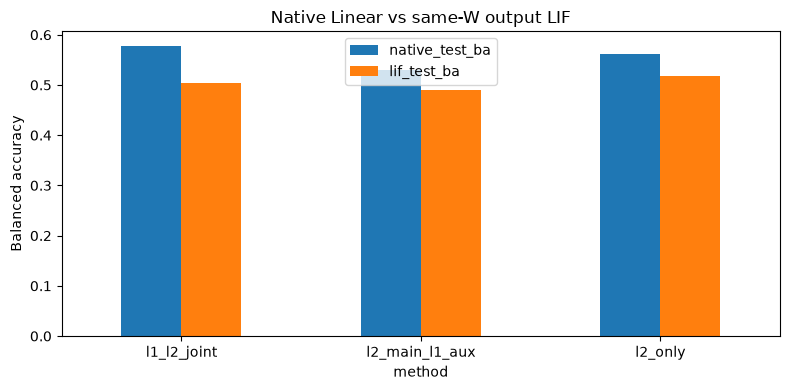

In [2]:
cols = ['method', 'native_test_ba_mean', 'native_test_ba_std', 'lif_test_ba_mean', 'lif_test_ba_std', 'lif_penalty_mean', 'parameter_count_mean']
display(method_summary[cols])
plot_df = method_runs.groupby('method')[['native_test_ba', 'lif_test_ba']].mean()
ax = plot_df.plot(kind='bar', figsize=(8, 4), rot=0)
ax.set_ylabel('Balanced accuracy')
ax.set_title('Native Linear vs same-W output LIF')
plt.tight_layout()

## Frozen L1/L2 representation probes

feature,l1_fixed250,l1_l2_fixed250,l1_l2_whole,l1_whole,l2_fixed250,l2_whole
method,,,,,,
l1_l2_joint,0.597434,0.634921,0.591707,0.610113,0.609438,0.585513
l2_main_l1_aux,0.555984,0.596169,0.593633,0.561727,0.588715,0.572135
l2_only,0.519498,0.575008,0.593077,0.571321,0.582325,0.545647


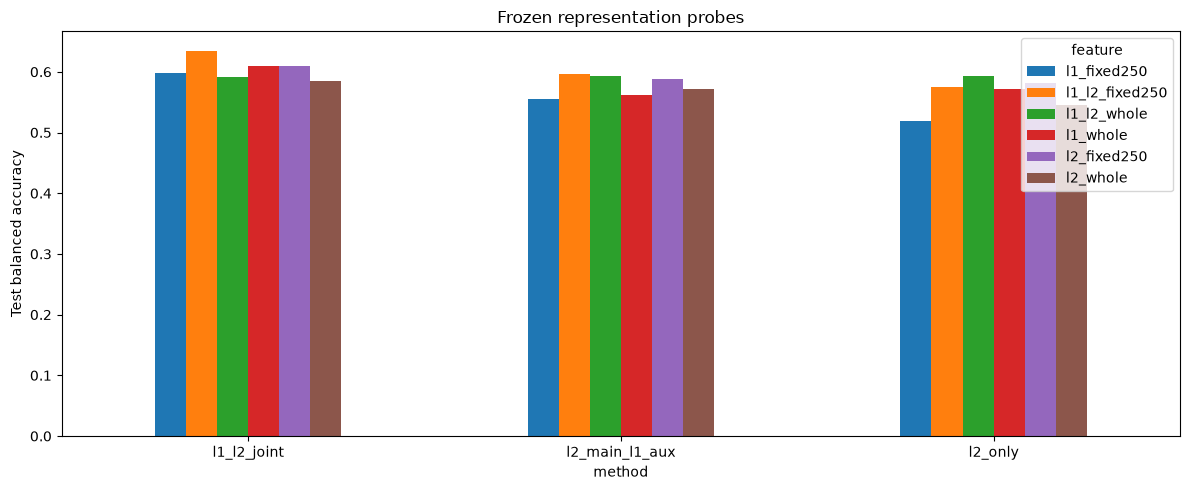

In [3]:
key_features = ['l1_whole', 'l2_whole', 'l1_l2_whole', 'l1_fixed250', 'l2_fixed250', 'l1_l2_fixed250']
view = probe_summary[probe_summary.feature.isin(key_features)][['method', 'feature', 'test_ba_mean', 'test_ba_std', 'train_test_gap_mean']]
display(view.pivot(index='method', columns='feature', values='test_ba_mean'))
pivot = probe_runs[probe_runs.feature.isin(key_features)].groupby(['method', 'feature']).test_ba.mean().unstack()
ax = pivot.plot(kind='bar', figsize=(12, 5), rot=0)
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Frozen representation probes')
plt.tight_layout()

## Does training create L1/L2 complementarity?

,method,fixed250_fusion_gain_over_best_single_mean,fixed250_fusion_gain_over_best_single_std,l1whole_l2fixed250_gain_over_l2fixed250_mean,l1whole_l2fixed250_gain_over_l2fixed250_std,reverse_mixed_gain_over_best_component_mean,reverse_mixed_gain_over_best_component_std,whole_fusion_gain_over_best_single_mean,whole_fusion_gain_over_best_single_std
0,l2_only,-0.007317,0.022908,-0.000541,0.006780,0.034458,0.024173,0.020078,0.017018
1,l1_l2_joint,0.025483,0.010020,0.007065,0.008383,0.037443,0.007319,-0.035167,0.058350
2,l2_main_l1_aux,0.007454,0.032641,-0.007728,0.012415,0.030681,0.024446,0.019379,0.036502


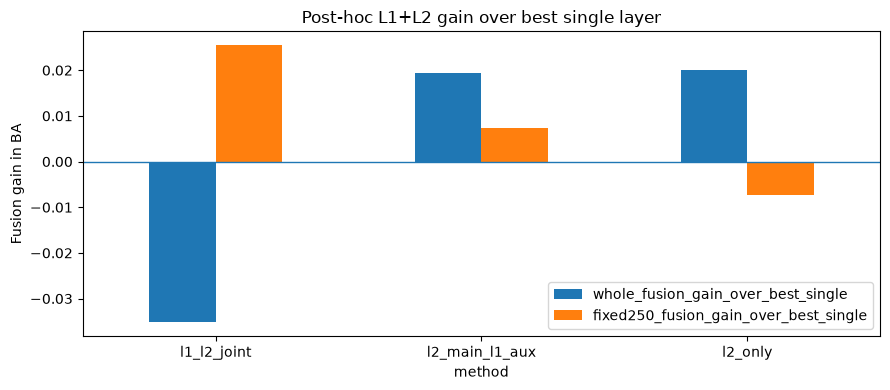

In [4]:
display(fusion_summary)
gain_cols = ['whole_fusion_gain_over_best_single', 'fixed250_fusion_gain_over_best_single']
gain = fusion_runs.groupby('method')[gain_cols].mean()
ax = gain.plot(kind='bar', figsize=(9, 4), rot=0)
ax.axhline(0, linewidth=1)
ax.set_ylabel('Fusion gain in BA')
ax.set_title('Post-hoc L1+L2 gain over best single layer')
plt.tight_layout()

## Correctness overlap and oracle union

In [5]:
test_overlap = overlap_summary[(overlap_summary.split == 'test')][['method', 'aggregation', 'l1_only_correct_mean', 'l2_only_correct_mean', 'prediction_disagreement_mean', 'oracle_union_accuracy_mean']]
display(test_overlap)

,method,aggregation,l1_only_correct_mean,l2_only_correct_mean,prediction_disagreement_mean,oracle_union_accuracy_mean
0,l2_only,fixed250,0.070776,0.139269,0.349315,0.668950
3,l2_only,whole,0.125571,0.100457,0.335616,0.680365
6,l1_l2_joint,fixed250,0.082192,0.089041,0.305936,0.703196
9,l1_l2_joint,whole,0.118721,0.089041,0.317352,0.716895
12,l2_main_l1_aux,fixed250,0.073059,0.109589,0.319635,0.675799
15,l2_main_l1_aux,whole,0.107306,0.116438,0.351598,0.691781


## Trained-head and probe block usage

In [6]:
display(head_summary)
joint_blocks = coef_summary[coef_summary.feature.isin(['l1_l2_whole', 'l1_l2_fixed250'])][['method', 'feature', 'layer', 'coef_rms_mean', 'coef_norm_fraction_mean']]
display(joint_blocks)

,method,head,coef_fro_norm_mean,coef_fro_norm_std,coef_rms_mean,coef_rms_std,coef_norm_fraction_mean,coef_norm_fraction_std
0,l2_only,l2,8.799944,0.337477,0.224535,0.008611,1.000000,0.000000
1,l1_l2_joint,l2,8.939638,0.378427,0.228100,0.009656,0.523074,0.011339
2,l1_l2_joint,l1,8.145887,0.028456,0.207847,0.000726,0.476926,0.011339
3,l2_main_l1_aux,l2,8.978365,0.198850,0.229088,0.005074,0.438423,0.007947
4,l2_main_l1_aux,l1,11.504217,0.427009,0.293536,0.010895,0.561577,0.007947


,method,feature,layer,coef_rms_mean,coef_norm_fraction_mean
1,l2_only,l1_l2_fixed250,l1,0.006732,0.341246
2,l2_only,l1_l2_fixed250,l2,0.012420,0.658754
3,l2_only,l1_l2_whole,l1,0.017060,0.274002
4,l2_only,l1_l2_whole,l2,0.045198,0.725998
13,l1_l2_joint,l1_l2_fixed250,l1,0.007193,0.341244
14,l1_l2_joint,l1_l2_fixed250,l2,0.013884,0.658756
15,l1_l2_joint,l1_l2_whole,l1,0.066734,0.296101
16,l1_l2_joint,l1_l2_whole,l2,0.151800,0.703899
25,l2_main_l1_aux,l1_l2_fixed250,l1,0.004651,0.344209
26,l2_main_l1_aux,l1_l2_fixed250,l2,0.008773,0.655791


## Mean training curves across seeds

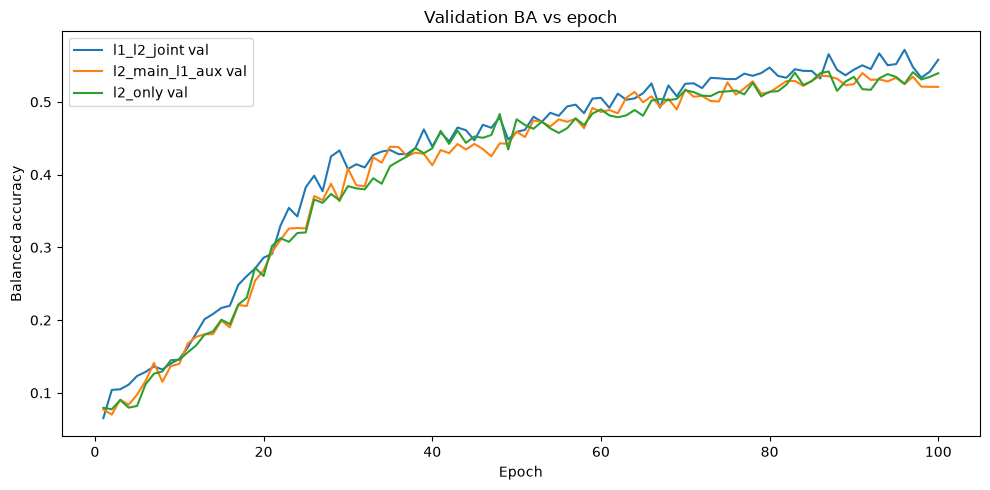

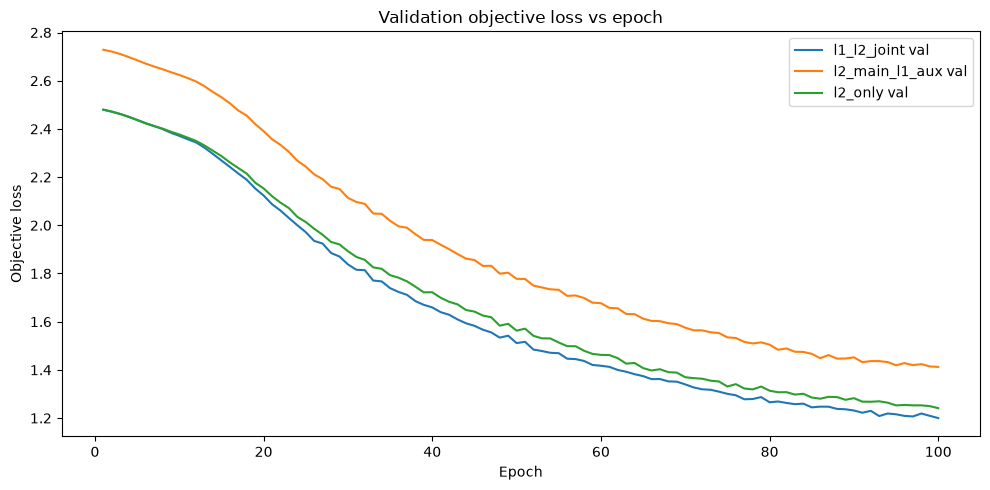

In [7]:
curve = history_runs.groupby(['method', 'epoch'], as_index=False)[['train_ba', 'val_ba']].mean()
fig, ax = plt.subplots(figsize=(10, 5))
for method, frame in curve.groupby('method'):
    ax.plot(frame.epoch, frame.val_ba, label=f'{method} val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Balanced accuracy')
ax.set_title('Validation BA vs epoch')
ax.legend()
plt.tight_layout()

curve_loss = history_runs.groupby(['method', 'epoch'], as_index=False)[['train_loss', 'val_loss']].mean()
fig, ax = plt.subplots(figsize=(10, 5))
for method, frame in curve_loss.groupby('method'):
    ax.plot(frame.epoch, frame.val_loss, label=f'{method} val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Objective loss')
ax.set_title('Validation objective loss vs epoch')
ax.legend()
plt.tight_layout()

## Interpretation checklist

1. Does `l1_l2_joint` improve native BA over `l2_only` across paired seeds?
2. Does frozen `L1+L2` probe gain become consistently positive after joint supervision?
3. Does `l2_main_l1_aux` improve L2-only representation while keeping inference L2-only?
4. Do L1-only-correct/L2-only-correct fractions increase or become more exploitable?
5. Does the trained joint head actually use both heads, or collapse onto one?